# Module 2: Predicting the reported biodiversity impact of Sustainable Land Management (SLM) technologies with supervised learning

**Research question:** Together with the data, WOCAT sent us a question that fits a supervised approach: which features of an SLM technology predict a large improvement in biodiversity? WOCAT is mainly interested in one indicator, **biomass / above-ground C** (questionnaire section 6.1). That is the amount of living plant matter and carbon stored above the soil surface. This notebook answers that question, and it adds the one WOCAT could ask next: among the documented SLM methods, which ones go with the largest reported biomass gains once we account for where they are applied?

**What this notebook builds on**

* Dima's data exploration gave us the tidy tables and two rules we follow throughout. Cross-validation is **grouped by country**, because sites and compilers cluster geographically. And the scores are **reported** impact, never a causal effect: compiler averages differ by two points on a seven-point scale.
* Norman's Module 1 clustering showed that the structure of the data is dominated by the agro-climatic zone. Environment first, practice second.

**What we do**

* One classical **yardstick**: logistic regression, which is the same thing as a network with no hidden layers. Its coefficients give the feature importances the research plan asks for. A second logistic regression uses a feature that turned out to matter, the number of answers the compiler ticked.
* **Method 1, a regularised deep feed-forward network**, with He initialisation, batch normalisation, dropout, L2, Adam, a learning-rate schedule and early stopping. We try four combinations of width and dropout.
* **Method 2, a multi-task network** that predicts the biomass high/low label and all eight biodiversity indicators of questionnaire section 6.1 at once, with a custom loss that tolerates missing indicators.
* **A check on the target:** We turn the -3 to +3 rating into a high/low label by splitting at the median (section 2 explains why). A model that keeps all seven steps then answers the same high/low question no better, so the split loses nothing.
* **A sensitivity check** on the target and the feature set.
* **The answer:** The multi-task network ranks the SLM methods as if they had all been applied in the same environments, and the agro-climatic zones as if they all carried the same practices. A permutation test shows which feature blocks the network actually uses.

**Key results, in short:** With biomass as the target and the research plan's input fields, the questionnaire predicts a technology's reported biomass gain only modestly. All 82 fields do no better than *two integers*: logistic regression on the number of degradation types and the number of measures a technology ticks reaches AUC 0.64 on unseen countries, the full field set 0.63, which is within one fold-to-fold standard deviation. The neural networks add nothing. Averaged over three seeds, the multi-task net reaches 0.60 and the feed-forward net 0.59, and the seed alone moves a network by several hundredths. The strongest signal in the data is therefore *how thoroughly a technology is described*. Of the technologies that address one degradation type, 17 % report the top biomass score, against 47 % of those that address five or more. Which method it is comes second. With the environment held fixed, ground cover, forest, windbreak and agroforestry lead the ranking while water harvesting and crop-livestock integration trail, but the whole ranking spans only eight probability points. The individual biodiversity indicators are not predictable beyond their means. The median split costs nothing: an ordinal model on the full seven-step scale reaches the same AUC on the binary question and explains 3 % of the variance in the rating. The clearest environmental signal is the agro-climatic zone. Arid and semi-arid sites report top biomass scores 1.5 to 2 times as often as humid and sub-humid ones.

Run time: about 6 minutes on a laptop CPU. Any Python environment with numpy, pandas, scikit-learn, matplotlib, tensorflow and keras will run it.

## 1. Setup


In [2]:
import os, sys, time, math, warnings
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"   # reproducible numerics on CPU

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

import sklearn
import tensorflow as tf
import keras
from keras import layers

warnings.filterwarnings("ignore", category=FutureWarning); warnings.filterwarnings("ignore", category=DeprecationWarning)
tf.get_logger().setLevel("ERROR")
SEED = 42
keras.utils.set_random_seed(SEED)

print(f"python {sys.version.split()[0]} | pandas {pd.__version__} | scikit-learn {sklearn.__version__} | "
      f"tensorflow {tf.__version__} | keras {keras.__version__}")

# plotting conventions
C_BLUE, C_ORANGE, C_AQUA, C_RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
INK, INK_MUTED, GRID, NEUTRAL = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
BLUES = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#3987e5", "#0d366b"])
BLUE_RED = LinearSegmentedColormap.from_list("blue_red", ["#104281", "#f0efec", "#b03030"])
plt.rc("font", size=11); plt.rc("axes", titlesize=12, labelsize=11, edgecolor=NEUTRAL, labelcolor=INK, axisbelow=True)
plt.rc("grid", color=GRID, linewidth=0.8); plt.rc("xtick", color=INK_MUTED); plt.rc("ytick", color=INK_MUTED)
plt.rc("legend", frameon=False, fontsize=10); plt.rc("figure", facecolor="white", dpi=100)

def tidy(ax, grid_axis="y"):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.grid(False)
    if grid_axis:
        ax.grid(True, axis=grid_axis)
    return ax

python 3.13.14 | pandas 3.0.5 | scikit-learn 1.9.1 | tensorflow 2.21.0 | keras 3.15.1


## 2. Data and targets

Two tables from Dima's notebook: one row per technology (1 540 rows, 51 columns) and one row per individual impact score (23 802 rows). The biodiversity block of the questionnaire (section 6.1) asks for a rating from -3 to +3 on eight indicators. A technology is scored only on the indicators its compiler considered relevant. Our research plan names one of them as the main output: **biomass / above-ground C**, the indicator WOCAT is mainly interested in. The other seven are optional outputs.

In [ ]:
def find_data_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "colab" / "datasets" / "wocat"
        if (candidate / "wocat_technologies.csv.gz").is_file():
            return candidate
    raise FileNotFoundError("run this notebook from inside the CAS-AML-WOCAT repository")

DATA = find_data_dir()
wocat = pd.read_csv(DATA / "wocat_technologies.csv.gz")
scores = pd.read_csv(DATA / "impact_scores.csv.gz")

PRETTY = {"vegetation_cover": "Vegetation cover", "biomass_above_ground_C": "Biomass / above-ground C",
          "plant_diversity": "Plant diversity", "animal_diversity": "Animal diversity",
          "beneficial_species": "Beneficial species", "habitat_diversity": "Habitat diversity",
          "invasive_alien_species": "Invasive alien species", "pest_disease_control": "Pest / disease control"}
BIO = list(PRETTY)
TARGET = "biomass_above_ground_C"          # the research plan's main output variable

bio_wide = (scores[scores["block"] == "ecological_biodiversity"]
            .pivot_table(index="technology_id", columns="indicator", values="value", aggfunc="mean").reindex(columns=BIO))
bio_all = wocat.merge(bio_wide, left_on="technology_id", right_index=True, how="inner").reset_index(drop=True)
bio_all["bio_mean"] = bio_all[BIO].mean(axis=1)                  # the secondary target of section 7.2
data = bio_all[bio_all[TARGET].notna()].reset_index(drop=True)   # the technologies that score biomass
MEDIAN = data[TARGET].median()
data["bio_high"] = (data[TARGET] > MEDIAN).astype(int)
y = data["bio_high"].to_numpy()
Y_IND = data[BIO].to_numpy(dtype=np.float32)          # NaN where an indicator was not scored

print(f"{len(wocat):,} technologies, {len(scores):,} individual scores; {len(bio_all)} technologies score at least one "
      f"biodiversity indicator, {len(data)} of them score biomass / above-ground C")
print(f"biomass score: median = {MEDIAN:+.0f}; share above {MEDIAN:+.0f} ('high') = {y.mean():.2f}; "
      f"share at or above {MEDIAN:+.0f} = {(data[TARGET] >= MEDIAN).mean():.2f}\n")
scored = bio_all[BIO].notna()
print(pd.DataFrame({"scored (all 895)": scored.sum().values, f"scored (the {len(data)} biomass records)": data[BIO].notna().sum().values,
                    "mean score": bio_all[BIO].mean().round(2).values, "share > 0": ((bio_all[BIO] > 0).sum() / scored.sum()).round(2).values},
                   index=[PRETTY[b] for b in BIO]).to_string())

1,540 technologies, 23,802 individual scores; 895 technologies score at least one biodiversity indicator, 479 of them score biomass / above-ground C
biomass score: median = +2; share above +2 ('high') = 0.30; share at or above +2 = 0.68

                          scored (all 895)  scored (the 479 biomass records)  mean score  share > 0
Vegetation cover                       350                               200        1.86       0.96
Biomass / above-ground C               479                               479        1.92       0.95
Plant diversity                        475                               291        1.75       0.93
Animal diversity                       249                               157        1.52       0.89
Beneficial species                     281                               175        1.64       0.94
Habitat diversity                      338                               208        1.54       0.88
Invasive alien species                  98                    

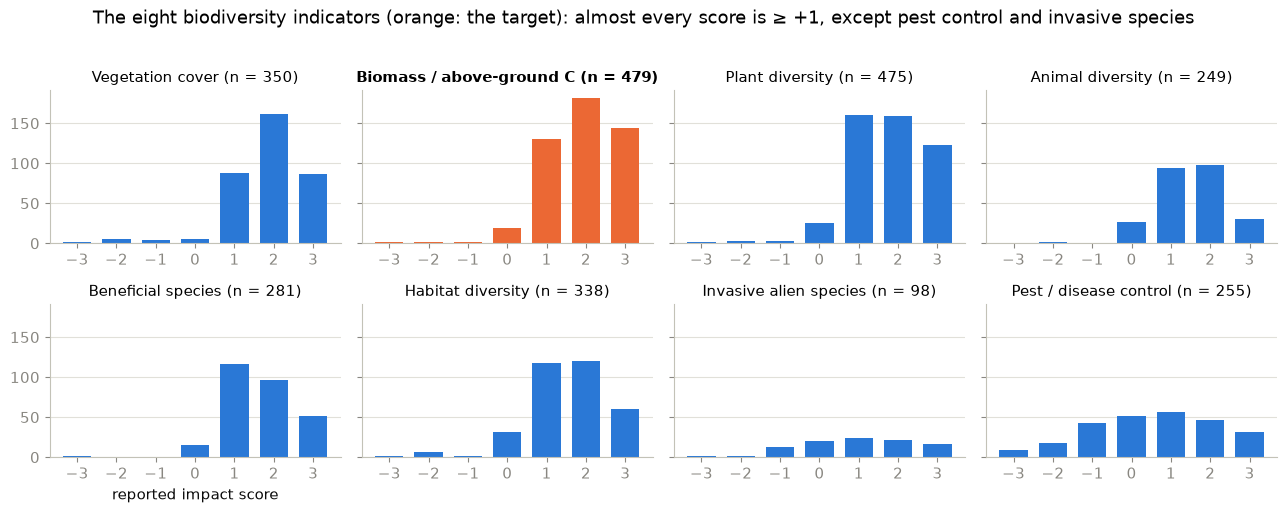

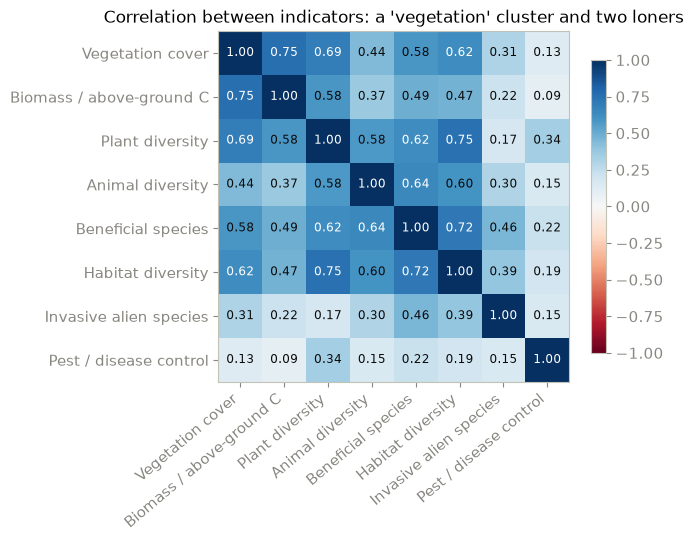

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5), sharey=True)
for ax, b in zip(axes.ravel(), BIO):
    counts = bio_all[b].round().value_counts().reindex(range(-3, 4), fill_value=0)
    ax.bar(counts.index, counts.values, color=C_ORANGE if b == TARGET else C_BLUE, width=0.72)
    ax.set_title(f"{PRETTY[b]} (n = {int(bio_all[b].notna().sum())})", fontsize=10.5, fontweight="bold" if b == TARGET else "normal")
    ax.set_xticks(range(-3, 4)); tidy(ax)
axes[1, 0].set_xlabel("reported impact score")
fig.suptitle("The eight biodiversity indicators (orange: the target): almost every score is ≥ +1, except pest control and invasive species", y=1.02)
plt.tight_layout(); plt.show()

corr = bio_all[BIO].corr()
fig, ax = plt.subplots(figsize=(6.8, 5.6))
im = ax.imshow(corr.values, cmap="RdBu", vmin=-1, vmax=1)
labels = [PRETTY[b] for b in BIO]
ax.set_xticks(range(8), labels, rotation=40, ha="right"); ax.set_yticks(range(8), labels)
for i in range(8):
    for j in range(8):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8.5, color="white" if abs(corr.values[i, j]) > 0.6 else INK)
ax.set_title("Correlation between indicators: a 'vegetation' cluster and two loners"); fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

**Target:** The research question asks which technologies report a *high* rather than a *low* improvement, so the target has to be a cut between the two, and the median is the natural place to put it. The label we build from it, `bio_high`, is 1 when a technology's biomass / above-ground C score sits above the median. The scores are whole numbers and the median is +2, a single step that holds 38 % of the records, so any median split puts that whole step on one side. "Above the median" therefore means **the top rating +3 against +2 or less**: 144 high against 335 low, a 30 / 70 split. "At or above the median" would count +2 as high as well (68 / 32), and splitting at zero would give 95 / 5. We keep the strict rule. Section 7.2 reports the other split, and section 6.5 checks the binary target against the full seven-step scale to make sure it loses nothing.

**Imbalance:** AUC stays the headline metric, because it depends neither on a threshold nor on the class balance. For macro-F1 and balanced accuracy, a model flags the **top 30 % or so of its test fold** by predicted probability, as many records as the training fold has high ones. The threshold is therefore a quantile of the model's own predictions rather than a fixed number. A cut at 0.5 would call almost everything low. A cut at the class share (0.30) would punish a model whose probabilities all run high or all run low without ranking any worse, which is exactly what the networks do (section 7.1). We do not use class weights. They would shift the decision the same way but distort the predicted probabilities, and section 7.3 reads those probabilities directly.

Only 479 of the 895 technologies with a biodiversity score rate biomass, so every model below trains and tests on those 479. The eight indicator columns, with `NaN` where an indicator was not scored, are the extra targets of the multi-task network. Their mean is the alternative target of section 7.2.

## 3. Features and the country-grouped split

The inputs are the Module 2 fields of the research plan, as far as Dima's table contains them, one-hot or multi-hot encoded into 82 binary features:

| research-plan field (questionnaire section) | role in the plan | used here |
|---|---|---|
| SLM group (3.5) | essential | ✅ `slm_group`, multi-answer |
| SLM measures (3.6) | essential | ✅ `measures`, multi-answer |
| Land degradation addressed (3.7) | essential | ✅ `degradation`, multi-answer |
| Groundwater table (5.4) | essential | ❌ not in the table (API key `groundwater`) |
| Availability of surface water | essential | ❌ not in the table (`surfacewater`) |
| Cost of establishment (4.4) and maintenance (4.6) | essential | ❌ not in the table (`establishment_cost_breakdown`, `maintenance_cost_breakdown`, local currencies) |
| Main purpose (3.1) | optional | ✅ `main_purpose`, multi-answer |
| Current land use | optional | ✅ `landuse`, multi-answer |
| Water supply | optional | ✅ `watersupply` |
| Agro-climatic zone (5.1) | optional | ✅ `agroclimatic_zone` |
| Slope (6.2) | optional | ✅ `slope` |
| Land use before the Technology (3.3) | optional | ❌ not in the table (`landuse_change`) |
| Tillage system (3.6) | optional | ❌ not in the table (`agronomic_tillage`) |
| Prevent / reduce / restore (3.8) | optional | ❌ not in the table (`prevention`) |
| Date of implementation (2.6) | optional | ❌ not in the table (`implementation_decades`) |
| Compiler (1.2), to control for bias | optional | not an input, see below |

The missing fields all exist in the raw API records, under the keys in brackets, but they were not flattened into the cached CSV. Adding them needs the WOCAT token. For the permutation test in section 7.4 the fields form three blocks: **environment** (agro-climatic zone, slope, water supply), **land use**, and **practice** (group, measures, degradation addressed, main purpose).

Some fields are **excluded on purpose**. Country and coordinates are used only to group the folds, because as features they would let the model memorise regions. `compiler_id` would teach the model who filled in the form, which does not transfer to unseen countries, and controlling for the compiler properly is a next step. The other `imp_*` blocks come from the same form and the same rater, and cost-benefit and adoption are outcome-like. Ten environment and context fields are left out because the research plan does not list them: rainfall, altitude, landform, soil depth, soil texture, topsoil organic matter, market orientation, mechanisation, land size and wealth. Section 7.2 shows what they do. Missing answers become their own category.

**Split:** Five folds, stratified on the label and grouped by country, fixed once and reused by every model. Inside each training fold, a further country-grouped 15 % serves as the validation set for early stopping. The test fold is never touched during training.

In [4]:
# the research plan's input fields that exist in Dima's table (the table above lists the ones that do not)
ENVIRONMENT = ["agroclimatic_zone", "slope", "watersupply"]
LAND_USE = ["landuse"]
PRACTICE = ["slm_group", "measures", "degradation", "main_purpose"]
SINGLE, MULTI = ENVIRONMENT, LAND_USE + PRACTICE
BLOCK_OF = {**{c: "environment" for c in ENVIRONMENT}, **{c: "land use" for c in LAND_USE}, **{c: "practice" for c in PRACTICE}}

from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score

def tokens(series):
    return series.apply(lambda v: v.split("|") if isinstance(v, str) and v else ["MISSING"])

def encode_onehot(df, single=SINGLE, multi=MULTI):
    frames = []
    for col in single:
        enc = OneHotEncoder(sparse_output=False, dtype=np.float32)
        arr = enc.fit_transform(df[[col]].fillna("MISSING").astype(str))
        frames.append(pd.DataFrame(arr, columns=[f"{col}={c}" for c in enc.categories_[0]], index=df["technology_id"]))
    for col in multi:
        mlb = MultiLabelBinarizer()
        arr = mlb.fit_transform(tokens(df[col]).tolist()).astype(np.float32)
        frames.append(pd.DataFrame(arr, columns=[f"{col}={c}" for c in mlb.classes_], index=df["technology_id"]))
    return pd.concat(frames, axis=1)

X_df = encode_onehot(wocat).loc[data["technology_id"]]
X = X_df.to_numpy(dtype=np.float32)
FIELD_OF = {c: c.split("=")[0] for c in X_df.columns}
groups = data["country_name"].to_numpy()

FOLDS = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED).split(X, y, groups))

def inner_split(train_idx, seed=SEED):
    tr, va = next(GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=seed).split(train_idx, groups=groups[train_idx]))
    return train_idx[tr], train_idx[va]

def scores_from(y_true, p, share_train):
    """AUC needs no threshold. Macro-F1 and balanced accuracy flag the top share_train of the fold by predicted probability
    (as many records as the training fold has 'high' ones): a quantile of the model's own predictions, so a model whose
    probabilities sit uniformly too high or too low is not punished twice. A constant prediction flags nothing."""
    yhat = (p > np.quantile(p, 1.0 - share_train)).astype(int)
    return {"AUC": roc_auc_score(y_true, p), "macro-F1": f1_score(y_true, yhat, average="macro"),
            "balanced acc.": balanced_accuracy_score(y_true, yhat)}

RESULTS = {}
def record(name, fold_scores, seconds):
    RESULTS[name] = {"folds": fold_scores, "seconds": seconds}
    df = pd.DataFrame(fold_scores)
    print(f"{name:40s} AUC {df['AUC'].mean():.3f} ± {df['AUC'].std():.3f}   macro-F1 {df['macro-F1'].mean():.3f} ± {df['macro-F1'].std():.3f}   ({seconds:4.0f} s)")

def summary_table():
    rows = []
    for name, r in RESULTS.items():
        df = pd.DataFrame(r["folds"])
        rows.append({"approach": name, "AUC": df["AUC"].mean(), "AUC sd": df["AUC"].std(), "macro-F1": df["macro-F1"].mean(),
                     "macro-F1 sd": df["macro-F1"].std(), "balanced acc.": df["balanced acc."].mean(), "seconds": r["seconds"]})
    return pd.DataFrame(rows).set_index("approach")

print(f"{X.shape[0]} technologies x {X.shape[1]} features; {len(set(groups))} countries")
print(pd.DataFrame([{"fold": k, "train": len(tr), "test": len(te), "test countries": len(set(groups[te])),
                     "share high (test)": round(y[te].mean(), 2)} for k, (tr, te) in enumerate(FOLDS)]).set_index("fold").to_string())

479 technologies x 82 features; 87 countries
      train  test  test countries  share high (test)
fold                                                
0       380    99              22               0.30
1       388    91              20               0.29
2       388    91              19               0.30
3       373   106               8               0.33
4       387    92              18               0.28


## 4. Yardstick: logistic regression

One classical model on the same folds. Logistic regression is the same model as a neural network with zero hidden layers, so the gap between it and the networks below measures exactly what hidden layers add: interactions between features. (We also ran a majority-class guess, which scores AUC 0.5 by construction, and a random forest of 500 trees. Neither is shown. The forest came out level with logistic regression on the same folds and put the same features at the top.)

The signed coefficients answer the research plan's question of how important the input features are. The cells after them check three things: the direction of the top features, one pattern behind them, and how far that pattern alone carries.

In [5]:
from sklearn.linear_model import LogisticRegression

make_logreg = lambda: LogisticRegression(C=0.3, max_iter=5000)

def cv_sklearn(make_model, X_, y_, folds):
    out = []
    for tr, te in folds:
        model = make_model().fit(X_[tr], y_[tr])
        out.append(scores_from(y_[te], model.predict_proba(X_[te])[:, 1], y_[tr].mean()))
    return out

def run_sklearn_cv(name, make_model):
    t0 = time.time()
    record(name, cv_sklearn(make_model, X, y, FOLDS), time.time() - t0)

run_sklearn_cv("0a. Logistic regression (82 fields)", make_logreg)


0a. Logistic regression (82 fields)      AUC 0.629 ± 0.035   macro-F1 0.627 ± 0.033   (   0 s)


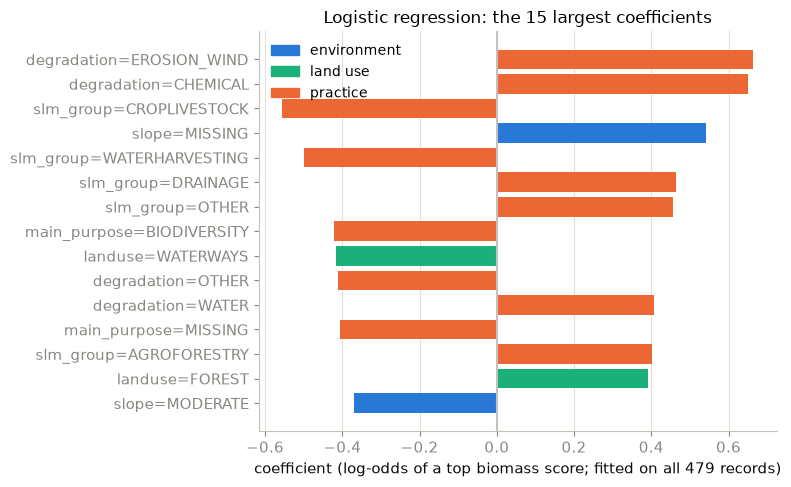

39 of 82 coefficients positive; blocks in the top 15: {'practice': 11, 'environment': 2, 'land use': 2}

                                 block  coefficient  prevalence  share high | present  share high | absent  difference
degradation=EROSION_WIND      practice        0.664       0.284                 0.426                0.251       0.176
degradation=CHEMICAL          practice        0.651       0.434                 0.389                0.232       0.157
slm_group=CROPLIVESTOCK       practice       -0.556       0.092                 0.159                0.315      -0.156
slope=MISSING              environment        0.541       0.019                 0.667                0.294       0.373
slm_group=WATERHARVESTING     practice       -0.498       0.067                 0.156                0.311      -0.155
slm_group=DRAINAGE            practice        0.465       0.035                 0.412                0.297       0.115
slm_group=OTHER               practice        0.457       0.06

In [6]:
logreg = make_logreg().fit(X, y)
coef = pd.Series(logreg.coef_[0], index=X_df.columns)
imp = coef.reindex(coef.abs().sort_values(ascending=False).index).head(15)   # the 15 largest coefficients, sign kept
present = {f: (X_df[f] == 1).to_numpy() for f in imp.index}
direction = pd.DataFrame({"block": [BLOCK_OF[FIELD_OF[f]] for f in imp.index],
                          "coefficient": imp.values,
                          "prevalence": [present[f].mean() for f in imp.index],
                          "share high | present": [y[present[f]].mean() for f in imp.index],
                          "share high | absent": [y[~present[f]].mean() for f in imp.index]}, index=imp.index)
direction["difference"] = direction["share high | present"] - direction["share high | absent"]

fig, ax = plt.subplots(figsize=(8, 5))
colours = {"environment": C_BLUE, "land use": C_AQUA, "practice": C_ORANGE}
ax.barh(imp.index[::-1], imp.values[::-1], color=[colours[BLOCK_OF[FIELD_OF[c]]] for c in imp.index[::-1]])
ax.axvline(0, color=NEUTRAL)
ax.legend(handles=[Patch(color=v, label=k) for k, v in colours.items()], loc="best")
ax.set_xlabel("coefficient (log-odds of a top biomass score; fitted on all 479 records)")
ax.set_title("Logistic regression: the 15 largest coefficients"); tidy(ax, "x")
plt.tight_layout(); plt.show()
print(f"{(coef > 0).sum()} of {len(coef)} coefficients positive; blocks in the top 15: {direction['block'].value_counts().to_dict()}\n")
print(direction.round(3).to_string())


In [7]:
ticked = pd.DataFrame({f: tokens(data[f]).apply(lambda t: 0 if t == ["MISSING"] else len(t)) for f in PRACTICE})
by_count = {}
for f in PRACTICE:
    k = ticked[f].where(ticked[f] > 0).clip(upper=5)
    by_count[f] = pd.Series(y).groupby(k).agg(lambda s: f"{s.mean():.2f} ({len(s)})").reindex([1, 2, 3, 4, 5])
by_count = pd.DataFrame(by_count).T.set_axis(["1", "2", "3", "4", "5+"], axis=1)
print("share of 'high' by the number of answers ticked in each multi-answer practice field (records in brackets):")
print(by_count.to_string())
print()
print("Spearman correlation of the count with the label:", ", ".join(f"{f} {pd.Series(y).corr(ticked[f], method='spearman'):+.2f}" for f in PRACTICE))

share of 'high' by the number of answers ticked in each multi-answer practice field (records in brackets):
                       1           2           3          4          5+
slm_group     0.24 (131)  0.35 (145)  0.28 (174)   0.50 (6)         NaN
measures      0.20 (166)  0.35 (161)  0.30 (100)  0.47 (47)    0.67 (3)
degradation   0.17 (100)  0.23 (119)  0.36 (122)  0.38 (88)   0.47 (49)
main_purpose   0.42 (81)   0.32 (77)   0.18 (55)  0.34 (53)  0.27 (157)

Spearman correlation of the count with the label: slm_group +0.01, measures +0.16, degradation +0.21, main_purpose -0.03


In [8]:
# the count as a predictor in its own right: two integers (degradation types and measures ticked) against the 82 fields
X_counts = ticked[["degradation", "measures"]].to_numpy(dtype=np.float32)
count_rows = []
for feats, Xv in [("two counts only", X_counts), ("82 one-hot fields (section 3)", X), ("82 fields + two counts", np.hstack([X, X_counts]))]:
    auc = pd.DataFrame(cv_sklearn(make_logreg, Xv, y, FOLDS))["AUC"]
    count_rows.append({"features": feats, "columns": Xv.shape[1], "AUC": auc.mean(), "sd": auc.std()})
print("the same folds and model, with the number of ticked answers as features:")
print(pd.DataFrame(count_rows).set_index("features").round(3).to_string())
print()
t0 = time.time()
record("0b. Logistic regression (two counts)", cv_sklearn(make_logreg, X_counts, y, FOLDS), time.time() - t0)


the same folds and model, with the number of ticked answers as features:
                               columns    AUC     sd
features                                            
two counts only                      2  0.636  0.066
82 one-hot fields (section 3)       82  0.629  0.035
82 fields + two counts              84  0.632  0.034

0b. Logistic regression (two counts)     AUC 0.636 ± 0.066   macro-F1 0.588 ± 0.061   (   0 s)


**Reading the coefficients:** Eleven of the fifteen largest coefficients belong to the *practice* block, and the two largest are degradation types. Technologies that address wind erosion report the top biomass score 43 % of the time against 25 % for the rest, 18 points more (coefficient +0.66). Chemical degradation adds 16 points (+0.65) and water degradation 13 (+0.41). The two clearest negatives are SLM groups: crop-livestock integration (16 % against 32 %, -0.56) and water harvesting (16 % against 31 %, -0.50), which also sit at the bottom of the what-if ranking in section 7.3. Drainage (+0.47, on only 17 records) and agroforestry (+0.40) point up, and so does forest as the land use (+0.39). The environment enters only through the slope, and weakly at that (moderate slopes -0.37, 6 points less).

Two of the fifteen rest on a handful of records and should be ignored: a missing slope answer (9 records, +0.54) and "other" as the degradation type (7 records, none of them high, -0.41). With 82 one-hot columns and 479 rows, a mild L2 penalty does not shrink rare categories to zero. One aside: technologies whose stated main purpose is biodiversity report a top biomass score *less* often than the rest (26 % against 32 %, -0.42).

**The count matters more than the type.** Three degradation types sit at the top of the list and all point upward, which makes the number of types ticked the obvious suspect. The first table confirms it. Of the technologies that address one degradation type, 17 % report a +3, against 47 % of those that address five or more (Spearman +0.21). For measures the share rises from 20 % at one measure to 47 % at four. The number of SLM groups or main purposes shows no such trend.

**Two integers match 82 fields.** The second table runs the same model and the same folds on three feature sets. A logistic regression on just the two counts reaches AUC 0.636, the full 82-field model 0.629, and both together 0.632. Nothing the individual answers say adds to what the number of answers says. A technology that tackles many problems at once may really build more biomass, but the count is also a trace of how thoroughly, and how enthusiastically, the compiler filled in the form. It is the rater effect Dima warned about, reaching the model through a feature this time rather than through the scores. The count model enters the results table of section 7.1 as yardstick 0b, and it is the one every later result has to be read against. Note that the coefficients above are signed but fitted on all 479 records at once, so they describe the fit rather than what transfers to unseen countries. Section 7.4 asks the transfer question with permutation importance on the test folds.

## 5. Method 1: a regularised deep feed-forward network

A multilayer perceptron on the 82 one-hot features, built with the Module 2 training toolbox:

| technique | what it does here |
|---|---|
| He initialisation | keeps activations at a sane scale through the layers |
| ReLU | non-saturating, no vanishing gradient |
| Batch normalisation | normalises inside the network, allows a larger learning rate (`use_bias=False` before it) |
| Dropout + L2 | the two regularisers that matter most with 480 rows |
| Adam | adaptive per-weight learning rates |
| `ReduceLROnPlateau` | halves the learning rate when the validation loss stalls |
| Early stopping | stops when the validation loss stops improving, restores the best weights |

We first show the failure mode without regularisation, then the regularised network, then we tune it. Every cross-validated network result is a mean over **5 folds and 3 seeds** (`run_keras_seeds`), because with about 380 training rows the random seed alone moves a network's AUC by several hundredths. One handicap to keep in mind: early stopping needs a validation set, so a network trains on about 323 of a fold's 380 rows and watches the other 57, while the yardstick of section 4 fits all 380.

In [9]:
def dense_trunk(h, hidden=(128, 64), dropout=0.3, l2=1e-4, batchnorm=True, activation="relu", name="trunk"):
    reg = keras.regularizers.l2(l2) if l2 else None
    for i, units in enumerate(hidden):
        h = layers.Dense(units, kernel_initializer="he_normal", use_bias=not batchnorm, kernel_regularizer=reg)(h)
        if batchnorm:
            h = layers.BatchNormalization()(h)
        h = layers.Activation(activation, name=f"{name}_out" if i == len(hidden) - 1 else None)(h)
        if dropout:
            h = layers.Dropout(dropout)(h)
    return h

def build_mlp(hidden=(128, 64), dropout=0.3, l2=1e-4, batchnorm=True, activation="relu", lr=1e-3):
    inp = keras.Input(shape=(X.shape[1],), name="onehot")
    out = layers.Dense(1, activation="sigmoid", name="bio_high")(dense_trunk(inp, hidden, dropout, l2, batchnorm, activation))
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="binary_crossentropy", metrics=[keras.metrics.AUC(name="auc")])
    return model

def callbacks(patience=15):
    return [keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)]

def run_keras_cv(build, Xany, extra_targets=None, name=None, epochs=150, batch_size=32, seed=SEED):
    """Grouped 5-fold CV for a Keras model whose (first) output is the bio_high sigmoid.
    build(train_idx) returns a compiled model. Returns (fold scores, fitted models, histories)."""
    t0, out, models, histories = time.time(), [], [], []
    for k, (tr, te) in enumerate(FOLDS):
        keras.utils.clear_session(); keras.utils.set_random_seed(seed + k)
        tr_in, va_in = inner_split(tr, seed + k)
        target = (lambda idx: y[idx]) if extra_targets is None else (lambda idx: {"bio_high": y[idx], **{n: t[idx] for n, t in extra_targets.items()}})
        model = build(tr_in)
        h = model.fit(Xany[tr_in], target(tr_in), validation_data=(Xany[va_in], target(va_in)),
                      epochs=epochs, batch_size=batch_size, callbacks=callbacks(), verbose=0)
        pred = model.predict(Xany[te], verbose=0)
        p = (pred["bio_high"] if isinstance(pred, dict) else pred).ravel()
        out.append(scores_from(y[te], p, y[tr].mean())); models.append(model); histories.append(h.history)
    if name:
        record(name, out, time.time() - t0)
    return out, models, histories

SEEDS = (SEED, 7, 123)
def run_keras_seeds(build, Xany, extra_targets=None, name=None):
    """run_keras_cv once per seed. On ~380 training rows the seed alone moves a network's AUC by several
    hundredths, so every network result below is a mean over 5 folds x 3 seeds. Models come back seed by seed,
    fold by fold: models[i] was tested on (FOLDS * len(SEEDS))[i]."""
    t0, out, models = time.time(), [], []
    for s in SEEDS:
        fold_scores, fold_models, _ = run_keras_cv(build, Xany, extra_targets, seed=s)
        out += fold_scores; models += fold_models
    if name:
        record(name, out, time.time() - t0)
    return out, models

build_mlp().summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ onehot (InputLayer)             │ (None, 82)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ trunk_out (Activation)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bio_high (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,521 (76.25 KB)

 Trainable params: 19,137 (74.75 KB)

 Non-trainable params: 384 (1.50 KB)

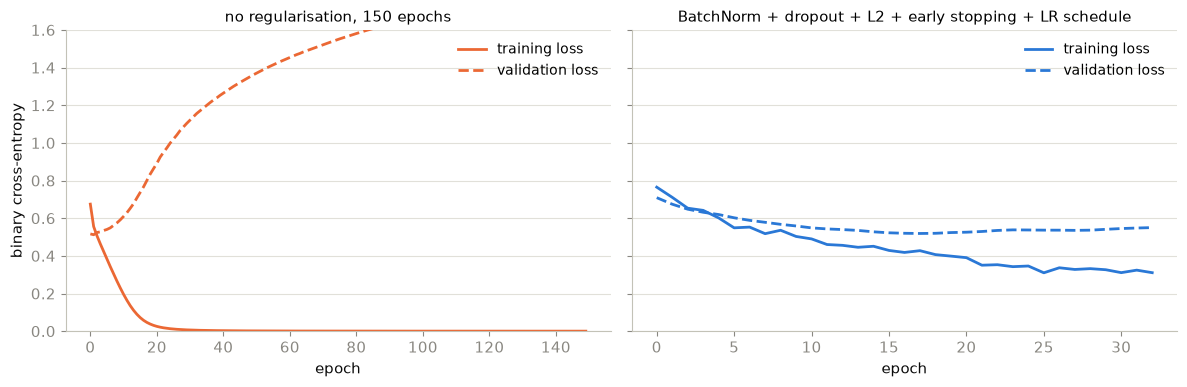

fold-0 test AUC: naive 0.638 (150 epochs)  |  regularised 0.615 (stopped after 33 epochs)


In [10]:
tr0, te0 = FOLDS[0]; tr_in0, va_in0 = inner_split(tr0)
keras.utils.set_random_seed(SEED)
naive = build_mlp(hidden=(256, 128), dropout=0.0, l2=0.0, batchnorm=False)
h_naive = naive.fit(X[tr_in0], y[tr_in0], validation_data=(X[va_in0], y[va_in0]), epochs=150, batch_size=32, verbose=0)
keras.utils.set_random_seed(SEED)
regular = build_mlp()
h_reg = regular.fit(X[tr_in0], y[tr_in0], validation_data=(X[va_in0], y[va_in0]), epochs=150, batch_size=32, callbacks=callbacks(), verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, hist, title, colour in [(axes[0], h_naive.history, "no regularisation, 150 epochs", C_ORANGE),
                                (axes[1], h_reg.history, "BatchNorm + dropout + L2 + early stopping + LR schedule", C_BLUE)]:
    ax.plot(hist["loss"], color=colour, linewidth=2, label="training loss")
    ax.plot(hist["val_loss"], color=colour, linewidth=2, linestyle="--", label="validation loss")
    ax.set_title(title, fontsize=11); ax.set_xlabel("epoch"); ax.legend(); tidy(ax)
axes[0].set_ylabel("binary cross-entropy"); axes[0].set_ylim(0, 1.6)
plt.tight_layout(); plt.show()
print(f"fold-0 test AUC: naive {roc_auc_score(y[te0], naive.predict(X[te0], verbose=0).ravel()):.3f} (150 epochs)  |  "
      f"regularised {roc_auc_score(y[te0], regular.predict(X[te0], verbose=0).ravel()):.3f} (stopped after {len(h_reg.history['loss'])} epochs)")

Left: the network memorises its ~320 training rows. The training loss falls to zero while the validation loss rises almost from the start. Right: with the toolbox the validation loss falls a little, flattens, and early stopping ends training after about thirty epochs. The single-fold test AUCs printed above come from one fold of 99 records and one seed. That the naive network happens to score higher there is exactly the kind of noise the next cell averages away. What this cell shows is the shape of the two loss curves, not which network scores better.

**Tuning:** Four configurations along the two axes that matter most on small data, width and dropout, each evaluated on the same grouped folds with three seeds. (Picking the best of four on the folds we report is slightly optimistic. Nested cross-validation would remove that, but with four candidates the effect is a fraction of an AUC point.)

In [11]:
SWEEP = {"narrow (64), no dropout": dict(hidden=(64,), dropout=0.0, l2=0.0),
         "narrow (64), dropout 0.3": dict(hidden=(64,), dropout=0.3, l2=1e-4),
         "wide (256-128), no dropout": dict(hidden=(256, 128), dropout=0.0, l2=0.0),
         "wide (256-128), dropout 0.5": dict(hidden=(256, 128), dropout=0.5, l2=1e-4)}
sweep, best = [], None
for label, cfg in SWEEP.items():
    t0 = time.time()
    fold_scores, _ = run_keras_seeds(lambda idx: build_mlp(**cfg), X)
    df = pd.DataFrame(fold_scores).assign(seed=np.repeat(SEEDS, len(FOLDS)))
    per_seed = df.groupby("seed", sort=False)["AUC"].mean()
    sweep.append({"config": label, "AUC": df["AUC"].mean(), **{f"AUC seed {s}": per_seed[s] for s in SEEDS},
                  "macro-F1": df["macro-F1"].mean(), "seconds": time.time() - t0})
    if best is None or df["AUC"].mean() > best[1]:
        best = (label, df["AUC"].mean(), fold_scores, time.time() - t0)
print(pd.DataFrame(sweep).set_index("config").round(3).to_string())
record(f"1. Feed-forward net ({best[0]})", best[2], best[3])

                               AUC  AUC seed 42  AUC seed 7  AUC seed 123  macro-F1  seconds
config                                                                                      
narrow (64), no dropout      0.576        0.576       0.557         0.596     0.560   54.056
narrow (64), dropout 0.3     0.582        0.578       0.565         0.605     0.560   52.779
wide (256-128), no dropout   0.589        0.619       0.542         0.604     0.573   48.402
wide (256-128), dropout 0.5  0.581        0.599       0.570         0.575     0.572   60.273
1. Feed-forward net (wide (256-128), no dropout) AUC 0.589 ± 0.056   macro-F1 0.573 ± 0.049   (  48 s)


All four configurations land between AUC 0.576 and 0.589, while the seeds within one configuration differ by up to 0.08. The selected one, wide without dropout, scores 0.619 with seed 42 and 0.542 with seed 7. The grid cannot separate the configurations, and a single-seed grid would simply have crowned the luckiest seed. What the regularisation toolbox buys on this data is training that is stable and stops by itself, not a higher score. The selected network reaches AUC 0.589, below logistic regression (0.629) and the two-count model (0.636). On 480 rows of one-hot answers, hidden layers find no interactions worth their extra variance, and we can say so only because the two logistic regressions are there to compare against.

## 6. Method 2: a multi-task network for all eight biodiversity indicators

The research plan names biomass as the main output and the other indicators of questionnaire section 6.1 as optional outputs, and section 2 showed they are correlated but not identical. So the network gets **two heads on one shared trunk**:

* `bio_high`, the same biomass high/low sigmoid classifier as method 1, trained with binary cross-entropy.
* `indicators`, eight linear outputs, one per indicator (biomass included), trained with a **masked mean squared error** that ignores the indicators a compiler did not score. The mask zeroes the error where the label is `NaN` and divides by the number of labels present.

The total loss is the weighted sum of the two, with weight 0.5 on the indicator head. The trunk has to serve nine targets at once, which regularises it, and the indicator head gives a prediction per indicator for every technology. That is the basis of the skill plot below and of the what-if in section 7.3. The trunk is method 1's default (128-64, dropout 0.3) rather than the grid's pick, because section 5 showed that the grid cannot tell the configurations apart.

In [12]:
def masked_mse(y_true, y_pred):
    mask = keras.ops.logical_not(keras.ops.isnan(y_true))
    y_true = keras.ops.where(mask, y_true, keras.ops.zeros_like(y_true))
    m = keras.ops.cast(mask, y_pred.dtype)
    return keras.ops.sum(keras.ops.square(y_true - y_pred) * m) / keras.ops.maximum(keras.ops.sum(m), 1.0)

def masked_mae(y_true, y_pred):
    mask = keras.ops.logical_not(keras.ops.isnan(y_true))
    y_true = keras.ops.where(mask, y_true, keras.ops.zeros_like(y_true))
    m = keras.ops.cast(mask, y_pred.dtype)
    return keras.ops.sum(keras.ops.abs(y_true - y_pred) * m) / keras.ops.maximum(keras.ops.sum(m), 1.0)

def build_multitask(indicator_bias=None, hidden=(128, 64), dropout=0.3, l2=1e-4, lr=1e-3, indicator_weight=0.5):
    inp = keras.Input(shape=(X.shape[1],), name="onehot")
    h = dense_trunk(inp, hidden, dropout, l2)
    out_high = layers.Dense(1, activation="sigmoid", name="bio_high")(h)
    # start the indicator head at the training means: from zero, early stopping (which watches the combined loss) halts
    # after ~5 epochs, before the head has learned the means of 1.5-1.9, and the per-indicator skill comes out spuriously negative
    bias_init = keras.initializers.Constant(indicator_bias) if indicator_bias is not None else "zeros"
    out_ind = layers.Dense(len(BIO), name="indicators", bias_initializer=bias_init)(h)
    model = keras.Model(inp, {"bio_high": out_high, "indicators": out_ind})
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss={"bio_high": "binary_crossentropy", "indicators": masked_mse},
                  loss_weights={"bio_high": 1.0, "indicators": indicator_weight},
                  metrics={"bio_high": [keras.metrics.AUC(name="auc")], "indicators": [masked_mae]})
    return model

scores_C, models_C = run_keras_seeds(lambda idx: build_multitask(indicator_bias=np.nanmean(Y_IND[idx], axis=0)),
                                     X, extra_targets={"indicators": Y_IND}, name="2. Multi-task net (8 indicators + high/low)")

2. Multi-task net (8 indicators + high/low) AUC 0.598 ± 0.074   macro-F1 0.571 ± 0.061   (  77 s)


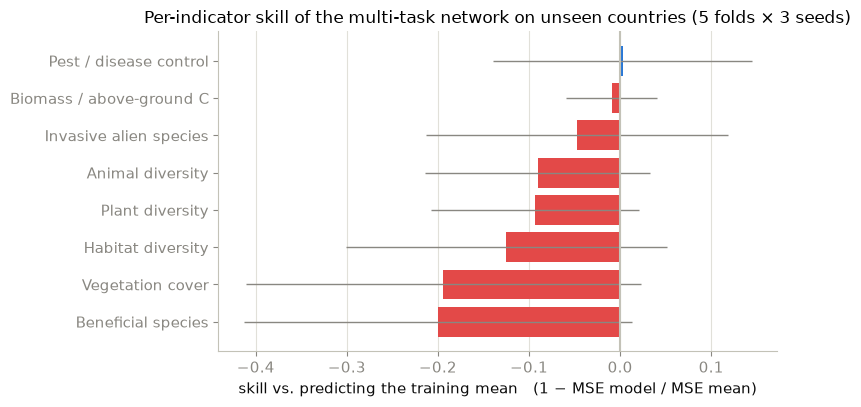

                             n  skill     sd
indicator                                   
Beneficial species         525 -0.200  0.213
Vegetation cover           600 -0.194  0.217
Habitat diversity          624 -0.125  0.176
Plant diversity            873 -0.094  0.114
Animal diversity           471 -0.090  0.123
Invasive alien species     174 -0.048  0.166
Biomass / above-ground C  1437 -0.009  0.050
Pest / disease control     396  0.003  0.142


In [13]:
rows = []
for model, (tr, te) in zip(models_C, FOLDS * len(SEEDS)):
    pred = model.predict(X[te], verbose=0)["indicators"]
    for j, b in enumerate(BIO):
        m = ~np.isnan(Y_IND[te, j])
        if m.sum() < 5:
            continue
        mse_model = np.mean((Y_IND[te, j][m] - pred[m, j]) ** 2)
        mse_mean = np.mean((Y_IND[te, j][m] - np.nanmean(Y_IND[tr, j])) ** 2)
        rows.append({"indicator": PRETTY[b], "n": int(m.sum()), "skill": 1 - mse_model / mse_mean})
skill = pd.DataFrame(rows).groupby("indicator").agg(n=("n", "sum"), skill=("skill", "mean"), sd=("skill", "std")).sort_values("skill")

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(skill.index, skill["skill"], xerr=skill["sd"], color=[C_BLUE if s >= 0 else C_RED for s in skill["skill"]], error_kw=dict(ecolor=INK_MUTED, lw=1))
ax.axvline(0, color=NEUTRAL); ax.set_xlabel("skill vs. predicting the training mean   (1 − MSE model / MSE mean)")
ax.set_title("Per-indicator skill of the multi-task network on unseen countries (5 folds × 3 seeds)"); tidy(ax, "x")
plt.tight_layout(); plt.show()
print(skill.round(3).to_string())

**Reading the skill plot:** Every bar sits between -0.2 and 0. On unseen countries the network predicts each biodiversity number *no better than that indicator's training mean*, biomass included (-0.01), even though the classification head finds some signal in the same data. (An AUC of 0.60 corresponds to a very small share of explained variance.) The questionnaire fields do not carry the information, not even for the strongly inter-correlated vegetation cluster. This is a result, not a failure of the method. It is the per-indicator version of Dima's warning, and it tells us to read the what-if of section 7.3 as the model's *tendencies* rather than as predictions. On the shared `bio_high` head the multi-task network is level with method 1: AUC 0.598 against 0.589, a difference far inside the seed-to-seed spread.

### 6.5 Does the median split throw information away?

Everything above predicts one bit: is the biomass score the top rating or not. The median split is our modelling choice, not part of WOCAT's question. The questionnaire offers seven steps, and section 7.2 shows that the headline depends on where the cut falls (AUC 0.629 at `> median`, 0.557 at `>= median`). If the binary target were a lossy shortcut, a model that sees the whole scale should beat it. This section runs that test: the same folds, the same 82 features and the same 479 records, with the raw -3 to +3 rating as the target, so the answer no longer depends on a threshold at all.

Three models. A **floor** that always answers the training median (+2). **Ridge regression**, which treats the rating as a plain number. And an **ordinal cumulative-link logit**: six logistic models, one per threshold `P(rating >= k)`, summed into an expected rating `E[y] = -3 + Σ_k P(y >= k)`. The ordinal model is the one that matters, because it *contains* the rest of the notebook. Its top threshold `P(rating >= +3)` **is** `bio_high`, and its middle threshold `P(rating >= +2)` is the `>= median` variant of section 7.2. The thresholds are fitted independently, so they can cross, and a fold may give `P(y >= +2) < P(y >= +3)`. The sum stays a usable score, but it is not a calibrated distribution over the seven levels.

**Measurements:** Spearman ρ is the headline. It is the rank-based generalisation of AUC (for a binary target, Somers' D = 2·AUC - 1) and it needs no threshold. MAE is read against the floor row. `skill` = 1 - MSE model / MSE mean is the same measure section 6 uses per indicator, so these numbers are directly comparable to the -0.009 the multi-task head scored on biomass. The last column scores the *same continuous prediction* against the *binary* target of section 7.1, which is what lets the two framings meet in one place.

In [14]:
# --- the raw -3...+3 rating as the target, on the folds and features of section 3 ---------------
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge

y_raw = data[TARGET].to_numpy(dtype=np.float64)   # the rating itself, not the median split
THRESHOLDS = np.arange(-2, 4)                     # P(y >= k) for every level above the minimum

def reg_scores(te, pred, tr):
    """Ordinal metrics on one test fold. The AUC column scores this same continuous prediction
    against the binary target of section 7.1, so it is directly comparable to that table."""
    resid, base = y_raw[te] - pred, y_raw[te] - y_raw[tr].mean()
    return {"Spearman": pd.Series(y_raw[te]).corr(pd.Series(pred), method="spearman") if pred.std() > 0 else np.nan,
            "MAE": np.abs(resid).mean(),
            "skill": 1 - np.mean(resid ** 2) / np.mean(base ** 2),
            "AUC (binary target)": roc_auc_score(y[te], pred)}

def fit_threshold(X_tr, y_tr):
    """One cumulative threshold. A fold in which the level never occurs gets a constant probability
    (only 4 of 479 records sit below 0, so the bottom thresholds are near-degenerate by construction)."""
    if y_tr.min() == y_tr.max():
        return lambda X_te: np.full(len(X_te), float(y_tr.mean()))
    model = make_logreg().fit(X_tr, y_tr)
    return lambda X_te: model.predict_proba(X_te)[:, 1]

def ordinal_predict(tr, te):
    """E[rating] = lowest level + sum_k P(rating >= k)."""
    p = [fit_threshold(X[tr], (y_raw[tr] >= k).astype(int))(X[te]) for k in THRESHOLDS]
    return THRESHOLDS[0] - 1 + np.sum(p, axis=0)

ORDINAL = {}
def record_reg(name, fold_scores, seconds):
    ORDINAL[name] = {"folds": fold_scores, "seconds": seconds}
    df = pd.DataFrame(fold_scores)
    spearman = "    –  " if df["Spearman"].isna().all() else f"{df['Spearman'].mean():+.3f}"   # a constant prediction has no rank
    print(f"{name:34s} Spearman {spearman}   MAE {df['MAE'].mean():.3f}   "
          f"skill {df['skill'].mean():+.3f}   AUC {df['AUC (binary target)'].mean():.3f}   ({seconds:4.0f} s)")

def cv_predictor(predict):
    return [reg_scores(te, predict(tr, te), tr) for tr, te in FOLDS]

for name, predict in [("0. Always the training median", lambda tr, te: DummyRegressor(strategy="median").fit(X[tr], y_raw[tr]).predict(X[te])),
                      ("1. Ridge regression on the rating", lambda tr, te: Ridge(alpha=10.0).fit(X[tr], y_raw[tr]).predict(X[te])),
                      ("2. Ordinal cumulative-link logit", ordinal_predict)]:
    t0 = time.time()
    record_reg(name, cv_predictor(predict), time.time() - t0)

ordinal_table = pd.DataFrame({k: pd.DataFrame(r["folds"]).mean() for k, r in ORDINAL.items()}).T
ordinal_table["seconds"] = [r["seconds"] for r in ORDINAL.values()]
print()
print(ordinal_table.round(3).to_string(na_rep="–"))
print(f"\nthe three comparisons: skill against 0.000  |  MAE against the floor row "
      f"({ordinal_table.loc['0. Always the training median', 'MAE']:.3f})  |  AUC against logistic "
      f"regression on the median split ({summary_table().loc['0a. Logistic regression (82 fields)', 'AUC']:.3f}, section 7.1)")


0. Always the training median      Spearman     –     MAE 0.684   skill -0.007   AUC 0.500   (   0 s)
1. Ridge regression on the rating  Spearman +0.198   MAE 0.753   skill -0.022   AUC 0.605   (   0 s)
2. Ordinal cumulative-link logit   Spearman +0.230   MAE 0.732   skill +0.033   AUC 0.632   (   0 s)

                                   Spearman    MAE  skill  AUC (binary target)  seconds
0. Always the training median             –  0.684 -0.007                0.500    0.009
1. Ridge regression on the rating     0.198  0.753 -0.022                0.605    0.025
2. Ordinal cumulative-link logit      0.230  0.732  0.033                0.632    0.134

the three comparisons: skill against 0.000  |  MAE against the floor row (0.684)  |  AUC against logistic regression on the median split (0.629, section 7.1)


**The median split throws nothing away.** Handed the whole scale, the ordinal model reaches **AUC 0.632** on the binary target. That is level with logistic regression's 0.629 in section 7.1, which was built for that exact question. Spearman comes out at **+0.230** and skill at **+0.033**. Three comparisons settle it, in the order in which they do so.

* **`skill` against 0:** +0.033 is the first skill number in this notebook that is positive by more than rounding. (Section 6's best was +0.003, for pest control, and the multi-task head managed -0.009 on this same indicator.) But it is 3 % of the variance in the rating. The questionnaire locates a technology on the seven-step scale barely better than the training mean does.
* **Ridge against the floor:** Treating the rating as a plain number does *worse* than answering +2 every time: skill -0.022, MAE 0.753 against the floor's 0.684, and AUC 0.605 on the binary question. What the ordinal model gains over ridge (+0.055 skill, +0.03 Spearman, +0.03 AUC) is what respecting the *order* of the scale buys. Both lose to the floor on MAE for the same reason. 38 % of the records sit exactly on +2, so answering +2 every time is very hard to beat on absolute error, and a model that spreads its predictions pays for every step it moves.
* **`AUC (binary target)` against 0.629:** This is where the two framings meet, and they meet almost exactly. The binary result was never really about the *median*. It was about +3 against the rest, the one boundary the questionnaire can see, and a model handed the whole scale finds its way back to the same boundary.

**So the split is the right resolution, not a loss.** A seven-step target would read better, since it gives an expected rating per SLM group instead of a probability on a cut. But the numbers printed on it would carry 3 % of the variance, and the MAE column says the point predictions are worse than answering +2 every time. The *order* of the groups would carry meaning, the values would not. The what-if in 7.3 therefore stays a probability of the top rating, and we keep the median split, because the model that saw all seven steps found nothing the split misses.

## 7. Results: which methods go with the largest reported biomass gains?

### 7.1 All models on the same folds


In [15]:
table = summary_table()
print(table.round(3).to_string())


                                                    AUC  AUC sd  macro-F1  macro-F1 sd  balanced acc.  seconds
approach                                                                                                      
0a. Logistic regression (82 fields)               0.629   0.035     0.627        0.033          0.628    0.055
0b. Logistic regression (two counts)              0.636   0.066     0.588        0.061          0.589    0.074
1. Feed-forward net (wide (256-128), no dropout)  0.589   0.056     0.573        0.049          0.574   48.402
2. Multi-task net (8 indicators + high/low)       0.598   0.074     0.571        0.061          0.571   77.149


Logistic regression on the 82 fields (AUC 0.629) and on the two counts (0.636) are tied within one fold-to-fold standard deviation, which runs from 0.03 to 0.07, and section 6.5's ordinal model joins the tie at 0.632 on this same binary target. Both networks sit 0.03 to 0.04 AUC below. Their standard deviations are larger partly because they pool seed variance with fold variance, 15 values against 5. With the quantile threshold the macro-F1 column tells the same story as AUC, 0.57 for the networks against 0.59 to 0.63 for the two logistic regressions, even though the networks' probabilities run high. (The multi-task ensemble predicts P(high) = 0.37 on average for a class that makes up 0.30, see section 7.3.) Every model is clearly above chance, but not by much. AUC 0.63 means that out of a random pair of one +3 record and one lower record, the model ranks the +3 higher 63 % of the time.

### 7.2 Sensitivity: does following the research plan matter?

Logistic regression on five variants of the problem: the biomass target split both ways, biomass with the ten extra fields, and the mean of all eight indicators (895 records) with both feature sets. Each variant gets its own stratified, country-grouped folds. The first row is the main analysis and repeats 0a.

In [16]:
EXTRA = ["rainfall", "altitude", "landform", "soil_depth", "soil_texture", "topsoil_organic",   # fields the research plan does not list
         "market_orientation", "mechanisation", "land_size", "wealth"]
X_research = encode_onehot(wocat)
X_extended = encode_onehot(wocat, SINGLE + EXTRA, MULTI)
biomass, mean8 = bio_all[TARGET], bio_all["bio_mean"]
VARIANTS = [  # (target, split, features, label, rows)
    ("biomass", "> median (+3 vs rest)", "plan fields", biomass > MEDIAN, biomass.notna()),
    ("biomass", ">= median (+2, +3 vs rest)", "plan fields", biomass >= MEDIAN, biomass.notna()),
    ("biomass", "> median (+3 vs rest)", "plan fields + 10 extra", biomass > MEDIAN, biomass.notna()),
    ("8-indicator mean", "> its median", "plan fields", mean8 > mean8.median(), mean8.notna()),
    ("8-indicator mean", "> its median", "plan fields + 10 extra", mean8 > mean8.median(), mean8.notna()),
]
rows = []
for target, split, feats, label, keep in VARIANTS:
    ids = bio_all.loc[keep, "technology_id"]
    Xv = (X_research if feats == "plan fields" else X_extended).loc[ids].to_numpy(dtype=np.float32)
    yv, gv = label[keep].astype(int).to_numpy(), bio_all.loc[keep, "country_name"].to_numpy()
    folds_v = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED).split(Xv, yv, gv))
    row = {"target": target, "split": split, "features": f"{feats} ({Xv.shape[1]})", "records": len(yv), "share high": yv.mean()}
    auc = pd.DataFrame(cv_sklearn(make_logreg, Xv, yv, folds_v))["AUC"]
    row["AUC"], row["sd"] = auc.mean(), auc.std()
    rows.append(row)
sensitivity = pd.DataFrame(rows)
print(sensitivity.round(3).to_string(index=False))

          target                      split                     features  records  share high   AUC    sd
         biomass      > median (+3 vs rest)             plan fields (82)      479       0.301 0.629 0.035
         biomass >= median (+2, +3 vs rest)             plan fields (82)      479       0.681 0.557 0.049
         biomass      > median (+3 vs rest) plan fields + 10 extra (148)      479       0.301 0.582 0.028
8-indicator mean               > its median             plan fields (82)      895       0.489 0.555 0.030
8-indicator mean               > its median plan fields + 10 extra (148)      895       0.489 0.515 0.034


Three things follow.

* **Biomass is the more predictable target.** With the same fields it reaches AUC 0.63 against 0.56 for the 8-indicator mean, on half the records. Averaging eight indicators mixes scores the form asks about for very different reasons, such as pest control and invasive species, and it dilutes the one WOCAT cares about most.
* **The ten extra fields hurt.** They cost 0.04 to 0.05 AUC on both targets: more one-hot columns for the same number of rows means more room to fit noise.
* **The split matters.** Moving the cut one step down (+2 and +3 against +1 or less, 68 / 32) drops the AUC to 0.56. The fields separate the top rating from the rest better than they separate modest from good ratings. We keep the strict split because it is the literal reading of "above the median", but it is also the easier one, which is why the other split is reported here.

### 7.3 Raw ranking vs. environment-adjusted what-if

The raw ranking mixes what a method does with *where* it is used. Forest technologies sit in humid zones, water harvesting in arid ones. The multi-task network lets us separate the two with a counterfactual: if every one of the 479 technologies had used method g, in its own climate, slope, water supply and land use, what would the network expect? We switch every technology's SLM-group indicators to *only* g, so a technology that listed several groups keeps just g, we leave everything else untouched, and we predict **out of fold**. Each record is scored only by the three multi-task models that did not train on it, one per seed, and the 479 scores are averaged. Predicting with all 15 models would let twelve of them recall records they were fitted on. In the plot, grey is the raw share of +3 biomass scores among technologies listing the group, and blue is the what-if probability. The cell after the plot repeats the what-if for the agro-climatic zone with practice and land use held fixed, the environment counterpart of the practice what-if.

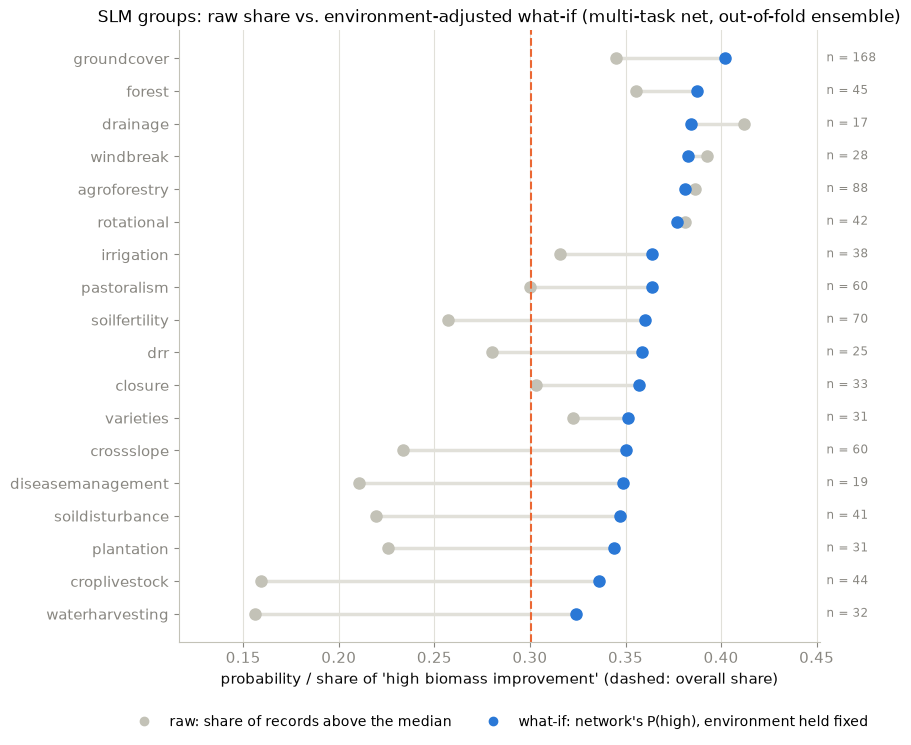

out-of-fold mean P(high) on the records as they are: 0.373; share of high records: 0.301

                     n  raw share high  adjusted P(high)
GROUNDCOVER        168           0.345             0.402
FOREST              45           0.356             0.387
DRAINAGE            17           0.412             0.384
WINDBREAK           28           0.393             0.383
AGROFORESTRY        88           0.386             0.381
ROTATIONAL          42           0.381             0.377
IRRIGATION          38           0.316             0.364
PASTORALISM         60           0.300             0.364
SOILFERTILITY       70           0.257             0.360
DRR                 25           0.280             0.359
CLOSURE             33           0.303             0.357
VARIETIES           31           0.323             0.351
CROSSSLOPE          60           0.233             0.350
DISEASEMANAGEMENT   19           0.211             0.349
SOILDISTURBANCE     41           0.220             0.34

In [17]:
long = data[["bio_high", TARGET]].assign(group=tokens(data["slm_group"])).explode("group")
share_high = long.groupby("group")["bio_high"].mean()
n_group = long.groupby("group").size()
GROUPS_SHOWN = [g for g in n_group.index if n_group[g] >= 15 and g not in ("MISSING", "OTHER")]
SLM_COL = {c.split("=")[1]: j for j, c in enumerate(X_df.columns) if c.startswith("slm_group=")}

MODEL_FOLDS = list(zip(models_C, FOLDS * len(SEEDS)))   # models_C[i] was tested on (FOLDS * len(SEEDS))[i]

def oof_predict(Xany, model_folds=MODEL_FOLDS):
    """Out-of-fold ensemble: every record is predicted only by the models that did not train on it (one per seed),
    and the seeds are averaged. Returns P(high) per record and the eight indicator predictions per record."""
    p_high = np.zeros((len(SEEDS), len(Xany))); p_ind = np.zeros((len(SEEDS), len(Xany), len(BIO)))
    for i, (m, (tr, te)) in enumerate(model_folds):
        pred = m.predict(Xany[te], verbose=0)
        p_high[i // len(FOLDS), te] = pred["bio_high"].ravel(); p_ind[i // len(FOLDS), te] = pred["indicators"]
    return p_high.mean(axis=0), p_ind.mean(axis=0)

def what_if(category):
    Xc = X.copy(); Xc[:, list(SLM_COL.values())] = 0.0; Xc[:, SLM_COL[category]] = 1.0
    p_high, p_ind = oof_predict(Xc)
    return p_high.mean(), p_ind.mean(axis=0)

P_OOF, IND_OOF = oof_predict(X)   # the records as they are, scored out of fold; reused in 7.4
adjusted = {}
for g in GROUPS_SHOWN:
    p, ind = what_if(g)
    adjusted[g] = {"adjusted P(high)": p, **{b: v for b, v in zip(BIO, ind)}}
adjusted = pd.DataFrame(adjusted).T.astype(float)
adjusted["raw share high"] = share_high.reindex(adjusted.index); adjusted["n"] = n_group.reindex(adjusted.index)
adjusted = adjusted.sort_values("adjusted P(high)")

fig, ax = plt.subplots(figsize=(9, 0.32 * len(adjusted) + 1.8))
for i, (g, r) in enumerate(adjusted.iterrows()):
    ax.plot([r["raw share high"], r["adjusted P(high)"]], [i, i], color=GRID, linewidth=2.5, zorder=1)
    ax.plot(r["raw share high"], i, "o", color=NEUTRAL, markersize=8, zorder=2)
    ax.plot(r["adjusted P(high)"], i, "o", color=C_BLUE, markersize=8, zorder=3)
    ax.text(1.01, i, f"n = {int(r['n'])}", va="center", fontsize=8.5, color=INK_MUTED, transform=ax.get_yaxis_transform())
ax.plot([], [], "o", color=NEUTRAL, label="raw: share of records above the median")
ax.plot([], [], "o", color=C_BLUE, label="what-if: network's P(high), environment held fixed")
ax.axvline(y.mean(), color=C_ORANGE, linestyle="--", linewidth=1.5)
values = adjusted[["raw share high", "adjusted P(high)"]].to_numpy()
ax.set_yticks(range(len(adjusted)), [g.lower() for g in adjusted.index]); ax.set_xlim(values.min() - 0.04, values.max() + 0.04)
ax.set_xlabel("probability / share of 'high biomass improvement' (dashed: overall share)")
ax.set_title("SLM groups: raw share vs. environment-adjusted what-if (multi-task net, out-of-fold ensemble)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2); tidy(ax, "x")
plt.tight_layout(); plt.show()
print(f"out-of-fold mean P(high) on the records as they are: {P_OOF.mean():.3f}; share of high records: {y.mean():.3f}\n")
print(adjusted[["n", "raw share high", "adjusted P(high)"]].round(3).sort_values("adjusted P(high)", ascending=False).to_string())

In [18]:
# the environment counterpart: switch every record's agro-climatic zone, practice and land use held fixed
ZONE_COL = {c.split("=")[1]: j for j, c in enumerate(X_df.columns) if c.startswith("agroclimatic_zone=")}
def what_if_zone(zone):
    Xz = X.copy(); Xz[:, list(ZONE_COL.values())] = 0.0; Xz[:, ZONE_COL[zone]] = 1.0
    return float(oof_predict(Xz)[0].mean())

zone_whatif = pd.Series({z: what_if_zone(z) for z in ZONE_COL if z != "MISSING"})
raw_by_zone = pd.Series(y, index=data.index).groupby(data["agroclimatic_zone"]).agg(["size", "mean"])
print("agro-climatic zone: raw share of top biomass scores, and the what-if P(high) with practice and land use held fixed")
print(pd.DataFrame({"n": raw_by_zone["size"], "raw share high": raw_by_zone["mean"].round(3), "what-if P(high)": zone_whatif.round(3)})
      .dropna().sort_values("raw share high", ascending=False).to_string())
slm_spread = adjusted["adjusted P(high)"].max() - adjusted["adjusted P(high)"].min()
print(f"\nwhat-if spread: SLM group {slm_spread:.3f} over {len(adjusted)} groups | zone {zone_whatif.max() - zone_whatif.min():.3f} over {len(zone_whatif)} zones")


agro-climatic zone: raw share of top biomass scores, and the what-if P(high) with practice and land use held fixed
            n  raw share high  what-if P(high)
ARID       49           0.449            0.397
SEMIARID  187           0.342            0.397
HUMID      48           0.229            0.367
SUBHUMID  188           0.229            0.345

what-if spread: SLM group 0.078 over 18 groups | zone 0.053 over 4 zones


Arid sites report a top biomass score in 45 % of records, semi-arid in 34 %, humid and sub-humid in 23 %. The what-if, which hands every record a different zone while keeping its practice and land use, keeps that order at 0.40, 0.40, 0.37 and 0.35. The zone spread (0.05) is narrower than the SLM-group spread (0.08), but four categories have less room to spread than eighteen, and section 7.4 shows that the network barely uses either block, which pushes both what-ifs towards the base rate. The raw shares are the part that stands on its own.

### 7.4 Which feature blocks does the network actually use?

Permutation importance on the test folds. We shuffle one block of columns at a time, all columns of a block together so that multi-hot rows stay valid, and measure the AUC each of the 15 multi-task models loses on its own test fold.

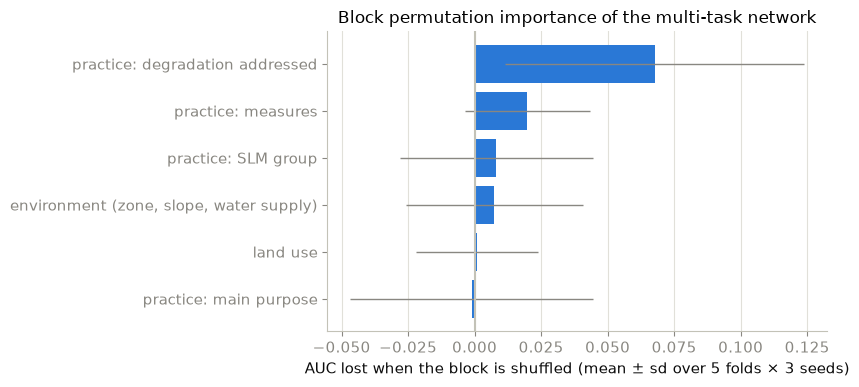

                                          mean    std
block                                                
practice: main purpose                  -0.001  0.046
land use                                 0.001  0.023
environment (zone, slope, water supply)  0.007  0.033
practice: SLM group                      0.008  0.036
practice: measures                       0.020  0.023
practice: degradation addressed          0.068  0.056


In [19]:
BLOCKS = {"environment (zone, slope, water supply)": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] in ENVIRONMENT],
          "land use": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] in LAND_USE],
          "practice: SLM group": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] == "slm_group"],
          "practice: measures": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] == "measures"],
          "practice: degradation addressed": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] == "degradation"],
          "practice: main purpose": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] == "main_purpose"]}
rng = np.random.default_rng(SEED); rows = []
for model, (tr, te) in zip(models_C, FOLDS * len(SEEDS)):
    base = roc_auc_score(y[te], model.predict(X[te], verbose=0)["bio_high"].ravel())
    for name, cols in BLOCKS.items():
        drops = []
        for _ in range(5):
            Xp = X[te].copy(); Xp[:, cols] = Xp[rng.permutation(len(te))][:, cols]
            drops.append(base - roc_auc_score(y[te], model.predict(Xp, verbose=0)["bio_high"].ravel()))
        rows.append({"block": name, "AUC drop": np.mean(drops)})
block_imp = pd.DataFrame(rows).groupby("block")["AUC drop"].agg(["mean", "std"]).sort_values("mean")
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.barh(block_imp.index, block_imp["mean"], xerr=block_imp["std"], color=C_BLUE, error_kw=dict(ecolor=INK_MUTED, lw=1))
ax.axvline(0, color=NEUTRAL); ax.set_xlabel("AUC lost when the block is shuffled (mean ± sd over 5 folds × 3 seeds)")
ax.set_title("Block permutation importance of the multi-task network"); tidy(ax, "x")
plt.tight_layout(); plt.show()
print(block_imp.round(3).to_string())

### 7.5 Synthesis

* **How much is ticked predicts more than what is ticked.** Two integers, the number of degradation types and the number of measures a technology addresses, reach AUC 0.636 on unseen countries. The 82 questionnaire fields reach 0.629, and both together 0.632 (section 4). The permutation test agrees from the network's side: shuffling the degradation block costs the multi-task network 0.07 AUC (± 0.06) and the measures block 0.02, while SLM group, environment, land use and main purpose cost nothing measurable (section 7.4). The strongest predictor of a reported top biomass score is how comprehensively a technology is described, which is as much a trace of the compiler as of the land.
* **Ground cover, forest, drainage, windbreak, agroforestry and rotational systems form the top group** of the what-if, with raw shares of 0.35 to 0.41 and out-of-fold what-if probabilities of 0.38 to 0.40. Drainage rests on 17 records. **Water harvesting and crop-livestock integration trail** in every view, with raw shares of 0.16 and last place in the what-if, and plantation, soil disturbance, disease management and cross-slope practices sit just above them. Among the 44 crop-livestock technologies the mean biomass rating is +1.70, against +2.04 for forest and +2.09 for agroforestry.
* **Holding the environment fixed changes the order only a little.** Ground cover (6th to 1st) and forest (5th to 2nd) gain, drainage (1st to 3rd) and crop varieties (7th to 12th) lose, and the bottom two stay. The what-if also compresses the range, from 0.16 to 0.41 down to 0.32 to 0.40. The network barely uses the SLM group (section 7.4), so switching it cannot move a probability far, and the level is off as well: mean P(high) 0.37 for a class share of 0.30. Read the order and the gaps, not the height of the blue dots.
* **The environment's signal is the agro-climatic zone.** Arid sites report a +3 in 45 % of records, semi-arid in 34 %, humid and sub-humid in 23 %, and the zone what-if keeps that order (0.40, 0.40, 0.37, 0.35). This is Module 1's "environment first" finding seen from the supervised side. The zone shows in the raw shares, the practice hardly shows at all.
* **The individual indicators are not predictable.** On unseen countries the multi-task network predicts none of the eight biodiversity indicators better than its training mean (skill -0.20 to 0.00, section 6), biomass included, while the same trunk's classification head reaches AUC 0.60. The questionnaire separates the top rating from the rest and locates very little else.

## 8. Conclusions and limitations

**Answer to the research question:** The WOCAT questionnaire predicts a technology's *reported* biomass gain only modestly, at AUC 0.63 on unseen countries, and the feature that carries the prediction is the *number* of degradation types and measures a technology addresses, which says as much about how the forms are filled in as about the land. Which method it is comes second. With the environment held fixed, ground cover, forest, windbreak and agroforestry lead, water harvesting and crop-livestock integration trail, and the whole ranking spans eight probability points. The environmental signal is the agro-climatic zone: arid and semi-arid sites report a top biomass score 1.5 to 2 times as often as humid and sub-humid ones.

**What the numbers cannot say:** Every score is one person's opinion of their own project. There are no failures and no control plots, and compilers who documented many technologies rate systematically higher or lower. The what-if is the network's belief about *reported* impact in a counterfactual it never observed. It describes what the WOCAT community reports, not what works. And this is not yet the full model of the research plan, because four of its seven essential inputs (groundwater table, surface water, establishment cost and maintenance cost) are missing from the cached data.

**Module 2 methods used:** A deep feed-forward network designed, trained, tuned and regularised with the D1 toolbox (method 1). A multi-output network built with the functional API and a custom masked loss (method 2, an extension of the course's multi-output and custom-loss examples). Grouped cross-validation repeated over three seeds, out-of-fold ensembling and permutation importance, for honest evaluation. On 479 rows of one-hot answers the networks find no interactions worth their extra variance, which the yardstick is there to detect. That is a result about the data, not a failure of the methods.

**Next steps:** The largest gap to the research plan's model is the data, not the model. Four of the seven essential inputs (groundwater table, surface water, establishment cost, maintenance cost) and four optional ones (land use before the technology, tillage, prevent / reduce / restore, implementation date) exist in the raw WOCAT API records but not in the cached CSV. Section 3 lists their keys. Fetching them needs the WOCAT API token, from Dima or the WOCAT secretariat, and an extension of Dima's flattening step. The costs are the messy part. They come as breakdowns in local currencies with an exchange rate per record, and they need converting to USD, probably on a log scale, before a model can use them. Two cheaper checks would sharpen the main finding. Compiler-grouped folds, the research plan's "control for bias", would measure how much of the signal is who filled in the form. And a comparison of the 479 technologies that have a biomass score with the 1 061 that do not would show whether the compilers who rate biomass are a particular kind.

## Appendix: how to run

* The notebook reads the two cached WOCAT tables (technologies and impact scores) from the repository's data folder, which it finds by walking up from the working directory. No API token is needed.
* Any Python environment with numpy, pandas, scikit-learn, matplotlib, tensorflow and keras installed will run the notebook, on whichever kernel you point it at. The results shown here were produced with Python 3.13, TensorFlow 2.21 (CPU), Keras 3, scikit-learn 1.9 and pandas 3, and the first code cell prints the versions it is actually running on.
* A full run takes about 6 minutes on a laptop CPU, because every network is trained 15 times. TensorFlow's import alone takes about 40 s. Seeds are fixed, so the logistic regressions and the sensitivity table reproduce exactly. The network results are means over three seeds and can still shift by a hundredth or two between machines and thread counts.